<a href="https://colab.research.google.com/github/cristian0527/MATH-244/blob/main/Homework_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MATH 244: Homework 6
## Cristian Castellanos
https://github.com/cristian0527/MATH-244/blob/main/Homework_6.ipynb

In [59]:
# load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_transformer
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.linear_model import ElasticNet, ElasticNetCV

In [60]:
# load datasets for homework
forest = pd.read_csv('forest.csv')
forest_area = pd.read_csv('forest_area.csv')
soy = pd.read_csv('soybean_use.csv')
veg = pd.read_csv('vegetable_oil.csv')
vdem = pd.read_csv('vdem_subset_hw3.csv')

#### Q1

The dimensions for soy are now a 8163 x 6 dataframe and for veg it is a 121199 x 5 dataframe

In [61]:
# drop na values in code values
forest_area = forest_area[pd.notnull(forest_area['code'])]
soy = soy[pd.notnull(soy['code'])]
veg  = veg[pd.notnull(veg['code'])]

In [62]:
# e_regionpol_6C
#vdem["e_regionpol_6C"].unique() -> array([2, 5, 4, 6, 1, 3])

vdem['e_regionpol_6C'] = vdem['e_regionpol_6C'].astype('category')

In [63]:
soy.shape

(8163, 6)

In [64]:
veg.shape

(121199, 5)

#### Q2

After pivoting the veg dataset, we get a 9323 x 15 dataframe

In [65]:
# veg
# pivoting veg by making the crop_oil names to be its own column

veg = veg.pivot(
    index=['code', 'year'],
    columns='crop_oil',
    values='production'
).reset_index()

veg.columns.name = None

In [66]:
# observing new veg df
veg.head(10)

,code,year,Coconut (copra),Cottonseed,Groundnut,Linseed,Maize,"Olive, virgin",Palm,Palm kernel,Rapeseed,Safflower,Sesame,Soybean,Sunflower
0,AFG,1961,NaN,4997.0,NaN,3531.0,NaN,82.0,NaN,NaN,NaN,NaN,2253.0,NaN,2938.0
1,AFG,1962,NaN,7716.0,NaN,3701.0,NaN,90.0,NaN,NaN,NaN,NaN,1876.0,NaN,3138.0
2,AFG,1963,NaN,11742.0,NaN,2857.0,NaN,82.0,NaN,NaN,NaN,NaN,1831.0,NaN,3138.0
3,AFG,1964,NaN,7960.0,NaN,3377.0,NaN,90.0,NaN,NaN,NaN,NaN,2722.0,NaN,3138.0
4,AFG,1965,NaN,7926.0,NaN,4327.0,NaN,82.0,NaN,NaN,NaN,NaN,2821.0,NaN,3238.0
5,AFG,1966,NaN,6453.0,NaN,4984.0,NaN,90.0,NaN,NaN,NaN,NaN,3149.0,NaN,3438.0
6,AFG,1967,NaN,7574.0,NaN,4962.0,NaN,82.0,NaN,NaN,NaN,NaN,3351.0,NaN,3439.0
7,AFG,1968,NaN,5625.0,NaN,2510.0,NaN,98.0,NaN,NaN,NaN,NaN,3579.0,NaN,3538.0
8,AFG,1969,NaN,7452.0,NaN,3014.0,NaN,82.0,NaN,NaN,NaN,NaN,3374.0,NaN,3638.0
9,AFG,1970,NaN,7847.0,NaN,5648.0,NaN,98.0,NaN,NaN,NaN,NaN,3488.0,NaN,3437.0


In [67]:
veg.shape

(9323, 15)

#### Q3

The mean of forest_change_per_sq_km is -4.038

In [68]:
vdem = vdem.rename(columns={'country_text_id': 'code'})

In [69]:
# merge datasets
deforest = (forest
    .merge(forest_area, on=['code', 'year'], how='inner')
    .merge(soy, on=['code', 'year'], how='inner')
    .merge(veg, on=['code', 'year'], how='inner')
    .merge(vdem, on=['code', 'year'], how='inner')
)

In [70]:
deforest.shape

(254, 30)

In [74]:
# observing columns
deforest["net_forest_conversion"]
deforest["e_area"]

In [77]:
deforest["forest_change_per_sq_km"] = ((deforest["net_forest_conversion"] * 100)/ deforest["e_area"])
np.mean(deforest["forest_change_per_sq_km"])

np.float64(-4.037987260445938)

#### Q4

In [79]:
# remove columns that are 30%, or above, missing
deforest_filtered = deforest.loc[:, deforest.isna().mean() < 0.30]

In [82]:
# drop na values from filtered deforest dataset
deforest_filtered = deforest_filtered.dropna()
deforest_filtered.shape

(168, 18)

In [106]:
# forest_area, code, entity, e_area, net_forest_conversion, forest_change_per_sq_km, country_name
# making a df called X that excludes the above columns

exclude = ['forest_area', 'code', 'entity_x', 'entity_y', 'e_area',
                'net_forest_conversion', 'forest_change_per_sq_km',
                'country_name', 'entity']

X = deforest_filtered.drop(columns=[col for col in exclude if col in deforest_filtered.columns])

X.shape # (168, 9)

(168, 9)

In [107]:
# df that contains code, entity, and year

country_years = deforest_filtered[['code', 'entity', 'year']]

In [108]:
y = deforest_filtered['forest_change_per_sq_km']

#### Q5

Visualization of Forest Change (sq/km) & Frequency.

The distribution is unimodal and normally distributed. For the tails, they both extend outwards to [-100, 100], though there are more values at the negative region of the tail, and go beyond -100. Centered at 0, and the peak here is high. Based off this, it means that most countries experience little to no forest change.

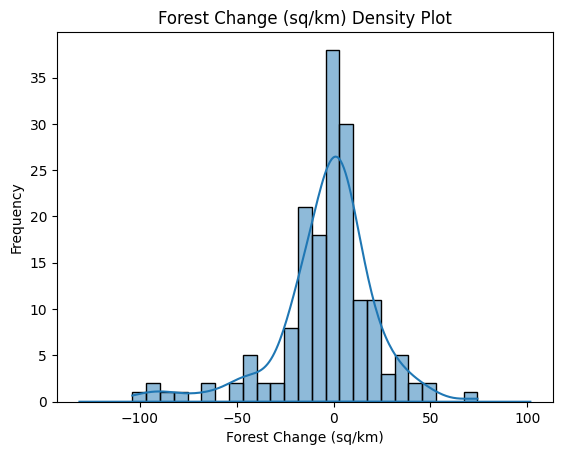

In [110]:
sns.kdeplot(y)
sns.histplot(y, kde=True)
plt.title('Forest Change (sq/km) Density Plot')
plt.xlabel('Forest Change (sq/km)')
plt.ylabel('Frequency')
plt.show()

#### Q6

In [111]:
group_kfold = GroupKFold(n_splits=10)

#### Q7

In [112]:
col_transformer = make_column_transformer(
    (OneHotEncoder(), ['e_regionpol_6C']),
    remainder=StandardScaler()
)

# OLS pipeline
pipeline_ols = Pipeline([
    ('preprocessor', col_transformer),
    ('model', LinearRegression())
])

# ridge pipeline
pipeline_ridge = Pipeline([
    ('preprocessor', col_transformer),
    ('model', RidgeCV(alphas=np.logspace(-5, 5, 100)))
])

# LASSO pipeline
pipeline_lasso = Pipeline([
    ('preprocessor', col_transformer),
    ('model', ElasticNetCV(alphas=np.logspace(-5, 5, 100), l1_ratio=1, max_iter=40000))
])

#### Q8

There are 10 elements in the three cross_validate() test score. The information that the test score tells us the negative MSE for the folds' test set (just how well the model performs for the countries that we left out)

In [113]:
# define function to run a cv_model on different pipelines

def cv_model(pipeline):
    cv_mod = cross_validate(
        pipeline,
        X,
        y,
        cv=group_kfold,
        groups=country_years['entity'],
        scoring='neg_mean_squared_error',
        return_estimator=True,
        n_jobs=1
    )
    return cv_mod

# fits
cv_ols   = cv_model(pipeline_ols)
cv_ridge = cv_model(pipeline_ridge)
cv_lasso = cv_model(pipeline_lasso)

In [125]:
# checking the different lengths of test scores in the 3 models
for i in [cv_ols, cv_ridge, cv_lasso]:
    print(len(i['test_score']))

10
10
10


#### Q9

MSE is conventionally postive, so I'm assuming this is just how Sklearn build their MSE. if we make it positive by multiplying by -1, we would get the regular MSE. The way I determined which model does the best is by turning the values positive, then finding the MSE mean. By doing so, the best model is LASSO

In [117]:
cv_ols['test_score']

array([ -856.88377235, -2235.26933578,  -209.91671231,  -247.72059302,
        -322.81261289,   -57.85513446, -5991.72220047,  -257.91934659,
        -416.25890768, -1592.24241443])

In [118]:
cv_lasso['test_score']

array([-1411.68291527, -2027.70705309,   -90.37848805,  -195.11549188,
        -260.48432801,  -118.65527487, -5973.05054602,  -169.46684213,
        -278.71044344, -1387.2757062 ])

In [119]:
cv_ridge['test_score']

array([ -894.5037019 , -2276.91945101,  -176.10629686,  -235.25686178,
        -275.53814571,   -44.68129746, -6510.8947573 ,  -214.82655123,
        -389.36925895, -1593.80561354])

In [126]:
# + MSE values, then finding the mean in each test CV model
for i in [cv_ols, cv_ridge, cv_lasso]:
    mse_scores = -i['test_score']
    print(mse_scores.mean())

1218.8601029976824
1261.1901935739584
1191.2527088957281


#### Q10

The coefficients across the 10 LASSO folds do not seem very stable. Many variables show high variance across coefficients. Also, with the dummy variables, the coefficients sway drastically, probably meaning that depending on the training set for each fold, the model becomes sensitive to some countries. Some of the dummy variables were also completely zeroed out for all folds (onehotencoder__e_regionpol_6C_5 and onehotencoder__e_regionpol_6C_6)

In [140]:
lasso_names = (cv_lasso['estimator'][0]
                 .named_steps['preprocessor']
                 .get_feature_names_out())

# df of coefficients across all 10 folds LASSO
coef_lasso = pd.DataFrame(
    [est.named_steps['model'].coef_ for est in cv_lasso['estimator']],
    columns=lasso_names
)

coef_lasso

,onehotencoder__e_regionpol_6C_1,onehotencoder__e_regionpol_6C_2,onehotencoder__e_regionpol_6C_3,onehotencoder__e_regionpol_6C_4,onehotencoder__e_regionpol_6C_5,onehotencoder__e_regionpol_6C_6,remainder__year,remainder__human_food,remainder__processed,remainder__Soybean,remainder__v2x_polyarchy,remainder__v2x_delibdem,remainder__e_gdppc,remainder__e_pop
0,0.000000,-0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,-0.000000,0.000000,0.000000,1.411829,0.000000
1,5.829014,-12.530280,0.000000,0.000000,-0.000000,-0.000000,1.369204,3.833564,-0.000000,-1.015776,0.000000,9.176238,0.000000,0.905340
2,12.383784,-6.912536,2.718241,-1.666102,0.000000,-0.000000,1.530661,1.935176,-0.000000,-2.492505,-18.826479,23.170423,1.093260,2.114913
3,12.996742,-4.492511,3.954050,-3.647588,0.000000,-0.000000,1.903020,2.594618,-0.000000,-3.013136,-18.887375,23.284843,0.852891,1.991312
4,16.767591,-3.996968,7.639924,-3.036597,0.009579,-0.020611,1.573474,3.009760,-0.454787,-0.000000,-23.882443,29.001631,0.402393,0.000000
5,1.208888,-8.753134,0.000000,-0.000000,0.000000,0.000000,1.041991,2.218957,-0.629072,-0.000000,-0.000000,4.076233,1.017827,0.798340
6,13.257058,-0.989616,0.000000,-1.687249,0.000000,0.000000,1.975204,-3.150045,-1.441101,-0.000000,-26.539295,31.355432,-0.000000,0.559786
7,15.806834,-3.579803,4.637671,-0.000000,0.000000,-0.000000,2.110825,1.212042,-0.000000,-2.037691,-26.021829,30.079307,0.854204,2.307012
8,0.000000,-7.199623,0.000000,-0.000000,0.000000,-0.000000,0.083243,0.335564,-0.000000,-0.000000,0.000000,1.012082,2.978581,1.186453
9,0.000000,-12.183923,0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,-0.000000,-0.000000,0.000000,1.912135,1.401604


In [147]:
len(list(coef_lasso.columns))

14

In [131]:
# in each fold, how many coefficients are zeroed out ->
(coef_lasso == 0).sum(axis=1)

,0
0,13
1,7
2,3
3,3
4,2
5,6
6,5
7,4
8,8
9,11


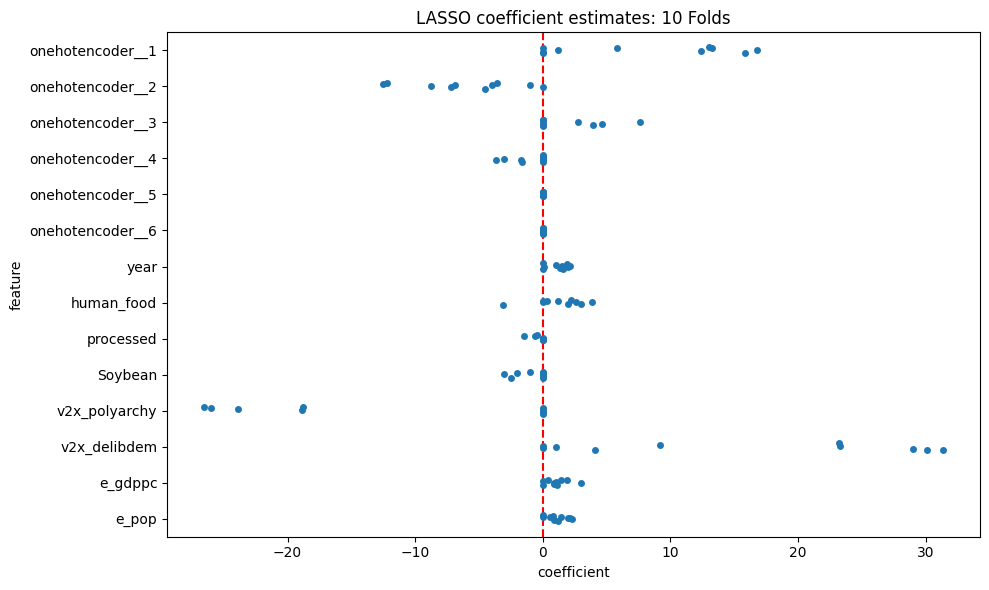

In [135]:
# strip the e_regionpol_6C_ prefix
coef_lasso.columns = [c.replace('e_regionpol_6C_', '').replace('remainder__', '')
                   for c in coef_lasso.columns]

# melt to long format for seaborn
# ...
coef_long = coef_lasso.melt(var_name='Feature', value_name='Coefficient')

# strip plot
plt.figure(figsize=(10, 6))
sns.stripplot(data=coef_long, x='Coefficient', y='Feature')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('LASSO coefficient estimates: 10 Folds')
plt.xlabel('coefficient')
plt.ylabel('feature')
plt.tight_layout()
plt.show()

#### Q11

The variables that seem most helpful in predicting deforestation across all folds are: e_pop, e_gdppc, year, and human_food. I ay this because they seem to be clustered well together.

#### Q12

The point of this approach is to evaluate how well our model predicts deforestation for countries it has never seen before.

What it can help us do better:
 * Select a model (OLS, LASSO, Ridge)
 * Identify variables that are useful predictors
 * Overall avoid overfitting


The trade-offs are:
* Less training data per fold
* Computationally expensive (N folds/iterations/)
* high variance

For finding the most optimal alpha, we cannot find the most optimal one because each fold is different (has different countries in the testing/training set). So based on that specific fold, there will be a different optimal alpha.

#### Q13

* When I ran my CV pipeline, it wasn't working and I was a bit confused so I asked a LLM of what the problem could be --> entity_x & entity_y existed, so I had to add them to my exclusion list.

* I was struggling with the strip plot and how to approach it, so I asked an LLM how to construct one for the coefficients of a model